# Beluga Benchmark Report

This cookbook shows how to explore and visualise APE results from a completed
Beluga benchmark run using . Run the benchmark first:

```bash
uv run lambkin examples/beluga/beluga_benchmark.py
```

Then open this notebook from the repository root and execute the cells.

In [30]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from lambkin.data import access
from lambkin.data import evo as evo_data

# Change this path if your results live elsewhere
RESULTS_DIR = Path.cwd() / "results"

print(RESULTS_DIR)
APE_FILE = "output.ape.zip"

/home/teresa/ekumen/lambkin/examples/beluga/results


## Explore available data

Inspect what variants and iterations are available before plotting.

In [31]:
iterations = access.iterations(RESULTS_DIR)

print(f"Total iterations: {len(iterations)}")
print()
for entry in iterations:
    label = ", ".join(f"{k}={v}" for k, v in sorted(vars(entry.params).items()))
    print(f"  {entry.variant} / iter {entry.iteration}  —  {label}")

Total iterations: 12

  var_1 / iter 0  —  num_particles=10, sensor_model=beam
  var_1 / iter 1  —  num_particles=10, sensor_model=beam
  var_2 / iter 0  —  num_particles=20, sensor_model=beam
  var_2 / iter 1  —  num_particles=20, sensor_model=beam
  var_3 / iter 0  —  num_particles=100, sensor_model=beam
  var_3 / iter 1  —  num_particles=100, sensor_model=beam
  var_4 / iter 0  —  num_particles=10, sensor_model=likelihood_field
  var_4 / iter 1  —  num_particles=10, sensor_model=likelihood_field
  var_5 / iter 0  —  num_particles=20, sensor_model=likelihood_field
  var_5 / iter 1  —  num_particles=20, sensor_model=likelihood_field
  var_6 / iter 0  —  num_particles=100, sensor_model=likelihood_field
  var_6 / iter 1  —  num_particles=100, sensor_model=likelihood_field


## APE timeseries by variant

Each variant is drawn in a distinct color. Individual iterations are shown
at reduced opacity; the per-variant mean is overlaid in bold.

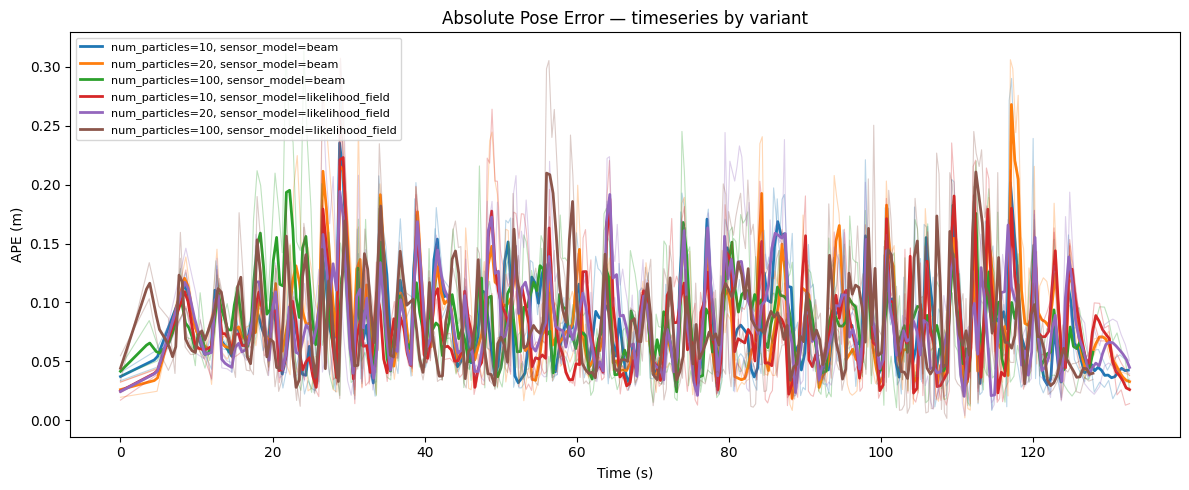

In [32]:
series = evo_data.series(RESULTS_DIR, APE_FILE)

by_variant = defaultdict(list)
for entry in series:
    by_variant[entry.variant].append(entry)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for (_variant, entries), color in zip(sorted(by_variant.items()), colors, strict=False):
    label = ", ".join(f"{k}={v}" for k, v in sorted(vars(entries[0].params).items()))
    for entry in entries:
        ax.plot(entry.time, entry.error, color=color, alpha=0.3, linewidth=0.8)
    t_min = max(e.time[0] for e in entries)
    t_max = min(e.time[-1] for e in entries)
    t_grid = np.linspace(t_min, t_max, 300)
    mean_error = np.mean([np.interp(t_grid, e.time, e.error) for e in entries], axis=0)
    ax.plot(t_grid, mean_error, color=color, linewidth=2, label=label)

ax.set_xlabel("Time (s)")
ax.set_ylabel("APE (m)")
ax.set_title("Absolute Pose Error — timeseries by variant")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "report_ape_series.png", dpi=150)
plt.show()

## Stats summary table

RMSE, mean, and max APE aggregated across iterations for each variant.

In [33]:
all_stats = evo_data.stats(RESULTS_DIR, APE_FILE)

by_variant_stats = defaultdict(list)
for entry in all_stats:
    label = ", ".join(f"{k}={v}" for k, v in sorted(vars(entry.params).items()))
    by_variant_stats[label].append(entry)

header = (
    f"{'Variant':<40} {'N':>4}"
    f" {'RMSE mean':>10} {'RMSE std':>10} {'Mean':>10} {'Max':>10}"
)
print(header)
print("-" * len(header))
for label in sorted(by_variant_stats):
    entries = by_variant_stats[label]
    rmse = [e.rmse for e in entries]
    print(
        f"{label:<40} {len(entries):>4}"
        f" {np.mean(rmse):>10.4f} {np.std(rmse):>10.4f}"
        f" {np.mean([e.mean for e in entries]):>10.4f}"
        f" {np.mean([e.max for e in entries]):>10.4f}"
    )

Variant                                     N  RMSE mean   RMSE std       Mean        Max
-----------------------------------------------------------------------------------------
num_particles=10, sensor_model=beam         2     0.0945     0.0022     0.0814     0.2890
num_particles=10, sensor_model=likelihood_field    2     0.0928     0.0030     0.0788     0.2624
num_particles=100, sensor_model=beam        2     0.0959     0.0055     0.0827     0.2795
num_particles=100, sensor_model=likelihood_field    2     0.0983     0.0065     0.0840     0.2701
num_particles=20, sensor_model=beam         2     0.0980     0.0054     0.0830     0.3067
num_particles=20, sensor_model=likelihood_field    2     0.0968     0.0062     0.0837     0.2653


## RMSE comparison across variants

Bar chart comparing RMSE per variant, with error bars showing ± std across iterations.

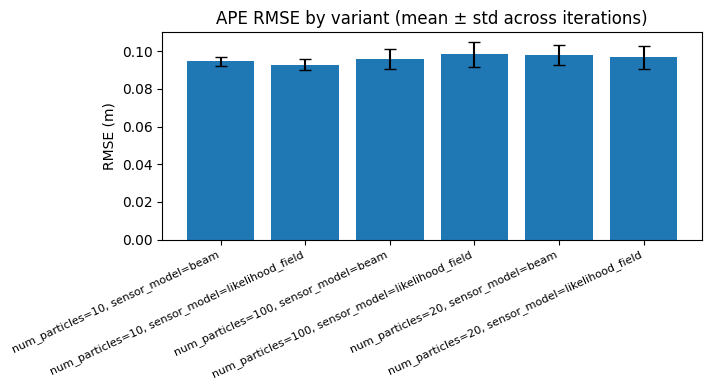

In [34]:
labels = sorted(by_variant_stats.keys())
rmse_means = [np.mean([e.rmse for e in by_variant_stats[lbl]]) for lbl in labels]
rmse_stds = [np.std([e.rmse for e in by_variant_stats[lbl]]) for lbl in labels]

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.2), 4))
x = np.arange(len(labels))
ax.bar(x, rmse_means, yerr=rmse_stds, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("RMSE (m)")
ax.set_title("APE RMSE by variant (mean ± std across iterations)")
fig.tight_layout()
plt.savefig(RESULTS_DIR / "report_rmse_bars.png", dpi=150)
plt.show()

## Convert to pandas DataFrame

For more advanced analysis — filtering, grouping, seaborn plots — convert the
results to a long-format DataFrame.  is an optional dependency; install
it with  if needed.

    sensor_model  num_particles variant  iteration     rmse     mean      max
            beam             10   var_1          0 0.092288 0.079131 0.287887
            beam             10   var_1          1 0.096761 0.083691 0.290193
            beam             20   var_2          0 0.103310 0.087182 0.307386
            beam             20   var_2          1 0.092606 0.078767 0.306057
            beam            100   var_3          0 0.101322 0.086457 0.313713
            beam            100   var_3          1 0.090396 0.079041 0.245192
likelihood_field             10   var_4          0 0.089870 0.075785 0.260752
likelihood_field             10   var_4          1 0.095775 0.081745 0.264075
likelihood_field             20   var_5          0 0.090617 0.080216 0.223788
likelihood_field             20   var_5          1 0.102970 0.087222 0.306910
likelihood_field            100   var_6          0 0.091779 0.079156 0.234772
likelihood_field            100   var_6          1 0.104731 0.08

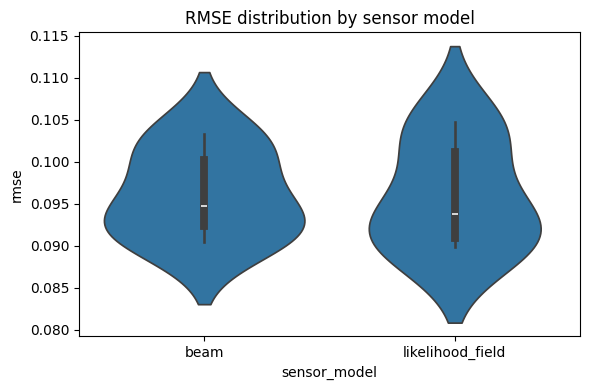

In [35]:
import pandas as pd
import seaborn as sns

rows = []
for entry in all_stats:
    row = vars(entry.params).copy()
    row["variant"] = entry.variant
    row["iteration"] = entry.iteration
    row["rmse"] = entry.rmse
    row["mean"] = entry.mean
    row["max"] = entry.max
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Example: violin plot of RMSE by sensor_model
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=df, x="sensor_model", y="rmse", ax=ax)
ax.set_title("RMSE distribution by sensor model")
fig.tight_layout()
plt.show()

## Export to HTML

Share the notebook as a standalone HTML file (no Jupyter required to open it):

```bash
jupyter nbconvert --to html examples/beluga/report.ipynb
```

This produces  in the same directory.